<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK10_study_0504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch5. 1~5 (p.308 ~ 337)

#5. 회귀

##5.1 회귀 소개
- "사람의 키는 평균 키로 회귀하려는 경향을 가진다"
- 여러 개의 독립변수와 한 개의 종속변수 간의 상관관계를 모델링하는 기법
- 독립변수: 피처, 종속변수: 결정 값
- 머신러닝 회귀 예측의 핵심 -> 주어진 피처와 결정 값 데이터 기반에서 학습을 통해 최적의 회귀 계수를 찾아내는 것
- 연속형 숫자 값
- 선형 회귀가 가장 많이 사용됨.
  - 실제 값과 예측값의 차이(오류의 제곱 값)를 최소화하는 직선형 회귀선을 최적화하는 방식
  - 규제 방법에 따라 다시 나뉨. (규제: 일반적인 선형 회귀의 과적합 문제를 해결하기 위해서 회귀 계수에 패널티 값을 적용하는 것)

[대표적인 선형 회귀 모델]
- 일반 선형 회귀
  - 예측값과 실제 값의 RSS(Residual Sum of Squares)를 최소화할 수 있도록 회귀 계수를 최적화하며, 규제(Regularization)을 적용하지 않은 모델
- 릿지(Ridge)
  - 선형 회귀에 L2 규제를 추가한 회귀 모델
  - L2 규제: 상대적으로 큰 회귀 계수 값의 예측 영향도를 감소시키기 위해서 회귀 계수값을 더 작게 만드는 규제 모델
- 라쏘(Lasso)
  - 선형 회귀에 L1 규제를 적용한 방식
  - L1 규제: 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않게 하는 것 (피처 선택 기능으로도 불림)
- 엘라스틱넷(ElasticNet)
  - L2, L1 규제를 결합한 모델
  - 피처가 많은 데이터 세트에서 적용되며, L1 규제로 피처의 개수를 줄임과 동시에 L2 규제로 계수 값의 크기를 조정.
- 로지스틱 회귀(Logistic Regression)
  - 분류에 사용되는 선형 모델. 강력한 분류 알고리즘
  - 이진 분류, 희소 영역의 분류(예: 텍스트 분류)에서 뛰어난 예측 성능을 보임.

##5.2 단순 선형 회귀를 통한 회귀 이해
- 오류(잔차): 실제 값과 회귀 모델의 차이에 따른 오류값
- 최적의 회귀 모델 -> 전체 데이터의 잔차(오류 값)합이 최소가 되는 모델
- 절댓값을 취해 더하거나, 오류 값의 제곱을 구해서 더하는 방식(RSS) 사용.
- RSS는 회귀식의 w 변수(회귀 계수)가 중심변수임.
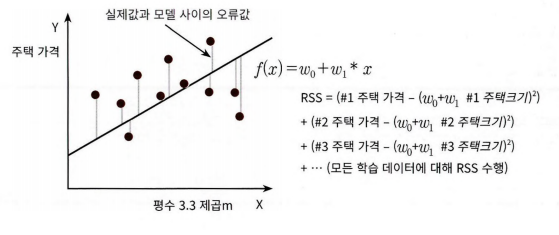

$$RSS(w_0, w_1) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (w_0 + w_1 * x_i))^2$$
($i$는 1부터 학습 데이터의 총 건수 $N$까지)

##5.3 비용 최소화하기 - 경사 하강법 (Gradient Descent) 소개
- W 파라미터가 많아지면 비용 함수 최소값을 고차원 방정식으로 직접 구하기 어렵다.
- 경사 하강법은 반복적으로 W 값을 업데이트해 비용 함수(RSS)를 점진적으로 줄이는 방법이다.
- 이 방식은 데이터 기반으로 스스로 학습하는 머신러닝의 핵심 기법이다.

- 경사 하강법은 어두운 산에서 낮은 방향으로 계속 내려가는 것처럼, 오류가 줄어드는 방향으로 W를 반복 업데이트하는 방법이다.
- 매 반복마다 예측값과 실제값의 차이(오류)를 줄이며, 더 이상 감소하지 않는 지점을 최소값으로 본다.
- 이 과정은 비용 함수의 미분(기울기)을 이용해 진행되며, 기울기가 0에 가까워질 때 최적의 W를 찾는다.
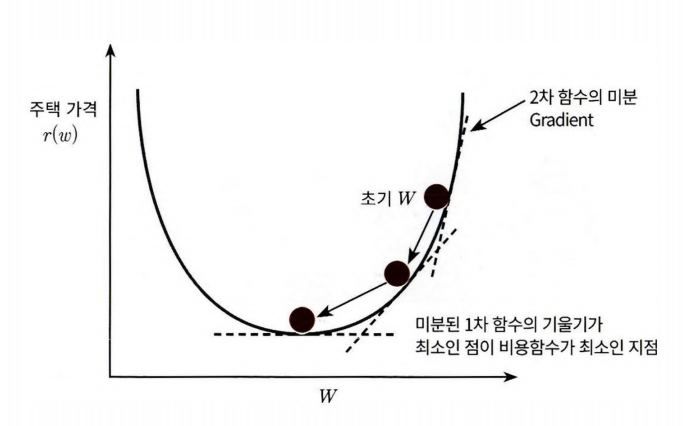

- 비용 함수 R(w)는 w₀, w₁ 두 파라미터를 가지므로 각각에 대해 편미분을 구해 최소값을 찾는다.
- 각 파라미터는 **이전 값 - 학습률 × (실제값 − 예측값 기반의 기울기)** 형태로 반복 업데이트된다.
- 초기값 설정 → 기울기 계산 → W 업데이트 → 비용 감소 확인 과정을 반복해 최적의 W를 찾는다.

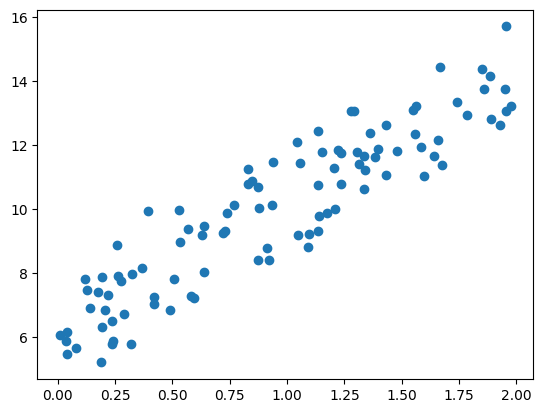

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4X + 6을 근사(w1=4, w0=6). 임의의 값은 노이즈를 위해 만듦.
X = 2 * np.random.rand(100,1)
y = 6 + 4 * X+np.random.randn(100,1)

# X, y 데이터 세트 산점도로 시각화
plt.scatter(X, y)

In [3]:
def get_cost(y, y_pred):
  N=len(y)
  cost=np.sum(np.sqare(y-y_pred))/N
  return cost

- 경사 하강법을 gradient_descent() 함수로 구현하며, 초기 w₀와 w₁을 0으로 설정하고 반복(iterations) 동안 계속 업데이트한다.
- 예측값은 y_pred = np.dot(X, w₁.T) + w₀로 계산하며, 이는 입력 데이터와 가중치의 내적을 이용한 것이다.
- 기울기(오차)를 기반으로 w₀, w₁의 업데이트 값을 넘파이 연산으로 구해 반복 적용해 최적값에 수렴시킨다.

In [1]:
# w1과 w0를 업데이트할 w1_update, w0_update를 반환.
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
  N = len(y)
  # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0값으로 초기화
  w1_update = np.zeros_like(w1)
  w0_update = np.zeros_like(w0)
  # 예측 배열 계산하고 예측과 실제 값의 차이 계산
  y_pred = np.dot(X, w1.T) + w0
  diff = y-y_pred

  # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
  w0_factors = np.ones((N,1))

  # w1과 w0을 업데이트할 w1_update와 w0_update 계산
  w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
  w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))

  return w1_update, w0_update

In [4]:
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함.
def gradient_descent_steps(X, y, iters=10000):
  # w0와 w1을 모두 0으로 초기화.
  w0 = np.zeros((1,1))
  w1 = np.zeros((1,1))

  # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행.
  for ind in range(iters):
    w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
    w1 = w1 - w1_update
    w0 = w0 - w0_update

  return w1, w0

In [5]:
def get_cost(y, y_pred):
  N = len(y)
  cost = np.sum(np.square(y - y_pred))/N
  return cost

w1, w0 = gradient_descent_steps(X, y, iters=100)
print("w1:{0:.3f} w0{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1:4.862 w05.058
Gradient Descent Total Cost:1.3596


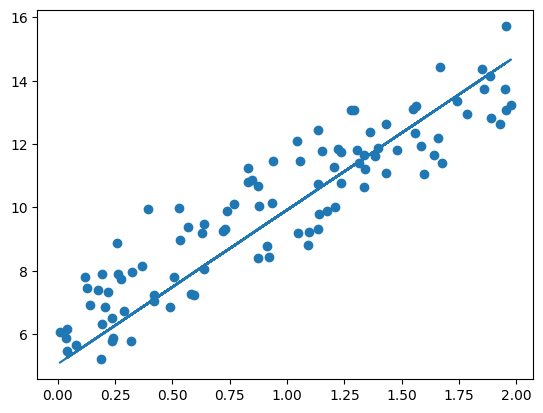

In [6]:
plt.scatter(X,y)
plt.plot(X, y_pred)

- 일반 경사 하강법은 모든 데이터를 사용해 반복 계산하므로 시간이 오래 걸리는 단점이 있다.
- 확률적 경사 하강법(SGD)은 일부 데이터(배치)만 사용해 빠르게 파라미터를 업데이트한다.
- 미니 배치 방식은 전체와 SGD의 절충으로, 랜덤 샘플을 사용해 효율적으로 최적값을 찾는다.

In [7]:
def stochastic_gradient_descent_steps(X,y,batch_size=10, iters=1000):
  w0 = np.zeros((1,1))
  w1 = np.zeros((1,1))

  for ind in range(iters):
    np.random.seed(ind)
    # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, sample_y로 저장
    stochastic_random_index = np.random.permutation(X.shape[0])
    sample_X = X[stochastic_random_index[0:batch_size]]
    sample_y = y[stochastic_random_index[0:batch_size]]
    # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
    w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
    w1 = w1 - w1_update
    w0 = w0 - w0_update

  return w1, w0

In [9]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print('w1:', round(w1[0,0],3), 'w0:', round(w0[0,0], 3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


- 미니 배치 확률적 경사 하강법은 일반 경사 하강법과 거의 비슷한 성능을 내면서 훨씬 빠르게 동작한다.
- 따라서 데이터가 클수록 전체 데이터 대신 일부를 사용하는 SGD 계열이 더 효율적이다.
- 피처가 여러 개인 경우에도 동일한 방식으로 확장되며, 피처 수만큼의 가중치(w)와 하나의 절편(w₀)을 학습한다.

- 여러 피처가 있는 경우 예측식은 $ y = w₀ + w₁x₁ + w₂x₂ + … $ 형태로 확장되며, 선형대수로 간단히 계산할 수 있다.
- 넘파이에서는 `np.dot(X, W.T)` 연산으로 모든 피처와 가중치를 한 번에 계산해 예측값을 구한다.
- 절편 w₀까지 포함하려면 X에 값이 1인 열을 추가해, 전체를 하나의 행렬 곱 $Y = X_{mat} \cdot W $로 표현할 수 있다.


##5.4 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

###LinearRegression 클래스 - Ordinary Least Squares
- 예측값과 실제 값의 RSS(Residual Sum of Squares)를 최소화해 OLS 추정 방식으로 구현한 클래스
- fit() 메서드로 X, y 배열을 입력받으면 회귀 계수(Coefficients)인 W를 coef_ 속성에 저장함.

In [12]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=1)
lr_model.fit(X, y)

LinearRegression(n_jobs=1)

[입력 파라미터]
- fit_intercept
  - 불린 값. 디폴트는 True.
  - Intercept(절편) 값을 계산할 것인지 말지를 지정함.
  - 만일 False로 지정하면 intercept가 사용되지 않고 0으로 지정됨.

- normalize
  - 불린 값. 디폴트는 False.
  - fit_intercept가 False인 경우에는 이 파라미터가 무시됨.
  - 만일 True이면 회귀를 수행하기 전에 입력 데이터 세트를 정규화함.

[속성]
- coef_
  - fit() 메서드를 수행했을 때 회귀 계수가 배열 형태로 저장하는 속성.
  - Shape는 (Target 값 개수, 피처 개수)
- intercept_
  - intercept 값
___
- OLS 회귀는 피처 간 상관관계가 높으면 다중공선성 문제로 분산이 커지고 모델이 불안정해진다.
- 이를 해결하기 위해 불필요한 피처를 제거하거나 규제(Regularization)를 적용한다.
- 피처가 많고 상관성이 클 경우 PCA 같은 차원 축소 기법을 활용하는 것도 방법이다.

###회귀 평가 지표
- 실제 값과 회귀 예측값의 차이 값을 기반으로 한 지표가 중심.
- 오류의 절댓값 평균이나 제곱, 또는 제곱한 뒤 다시 루트를 씌운 평균값을 구함.

| 평가 지표 | 설명 | 수식 |
| :--- | :--- | :--- |
| **MAE** | Mean Absolute Error(MAE)이며 실제 값과 예측값의 차이를 절댓값으로 변환해 평균한 것. | $MAE = \frac{1}{n} \sum_{i=1}^{n} \left| Y_i - \hat{Y}_i \right|$ |
| **MSE** | Mean Squared Error(MSE)이며 실제 값과 예측값의 차이를 제곱해 평균한 것. | $MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$ |
| **RMSE** | MSE 값은 오류의 제곱을 구하므로 실제 오류 평균보다 더 커지는 특성이 있으므로 MSE에 루트를 씌운 것이 RMSE(Root Mean Squared Error)입니다. | $RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2}$ |
| **R²** | 분산 기반으로 예측 성능을 평가. 실제 값의 분산 대비 예측값의 분산 비율을 지표로 하며, 1에 가까울수록 예측 정확도가 높음. | $R^2 = \frac{\text{예측값 } Variance}{\text{실제값 } Variance}$ |

| 평가 방법 | 사이킷런 평가 지표 API | Scoring 함수 적용 값 |
| :--- | :--- | :--- |
| **MAE** | `metrics.mean_absolute_error` | `'neg_mean_absolute_error'` |
| **MSE** | `metrics.mean_squared_error` | `'neg_mean_squared_error'` |
| **RMSE** | `metrics.mean_squared_error`를 그대로 사용하되 `squared` 파라미터를 `False`로 설정. | `'neg_root_mean_squared_error'` |
| **MSLE** | `metrics.mean_squared_log_error` | `'neg_mean_squared_log_error'` |
| **R²** | `metrics.r2_score` | `'r2'` |

- 사이킷런의 Scoring 함수는 값이 클수록 좋은 모델로 평가하기 때문에, 오류 기반 지표(MAE 등)에 neg_를 붙여 음수로 변환한다.
- 예를 들어 neg_mean_absolute_error는 실제로 -1 × MAE 값을 의미한다.
- 따라서 Scoring 결과는 음수로 나오지만, 실제 해석 시에는 절댓값(양수)으로 다시 이해해야 한다.

###LinearRegression을 이용해 보스턴 주택 가격 회귀 구현

In [15]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
bostonDF = pd.DataFrame(data, columns=feature_names)
bostonDF['PRICE'] = target

print('Boston 데이터 세트 크기 :', bostonDF.shape)
display(bostonDF.head())

Boston 데이터 세트 크기 : (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


- 데이터는 Null 값이 없고 모두 float 타입이며, info()로 확인할 수 있다.
- 주요 피처 8개(RM, ZN, INDUS, NOX, AGE, PTRATIO, LSTAT)가 PRICE에 미치는 영향을 회귀선(regplot)으로 시각화한다.
- subplots(nrows=2, ncols=4)를 사용해 총 8개의 그래프를 한 번에 배치해 비교한다.

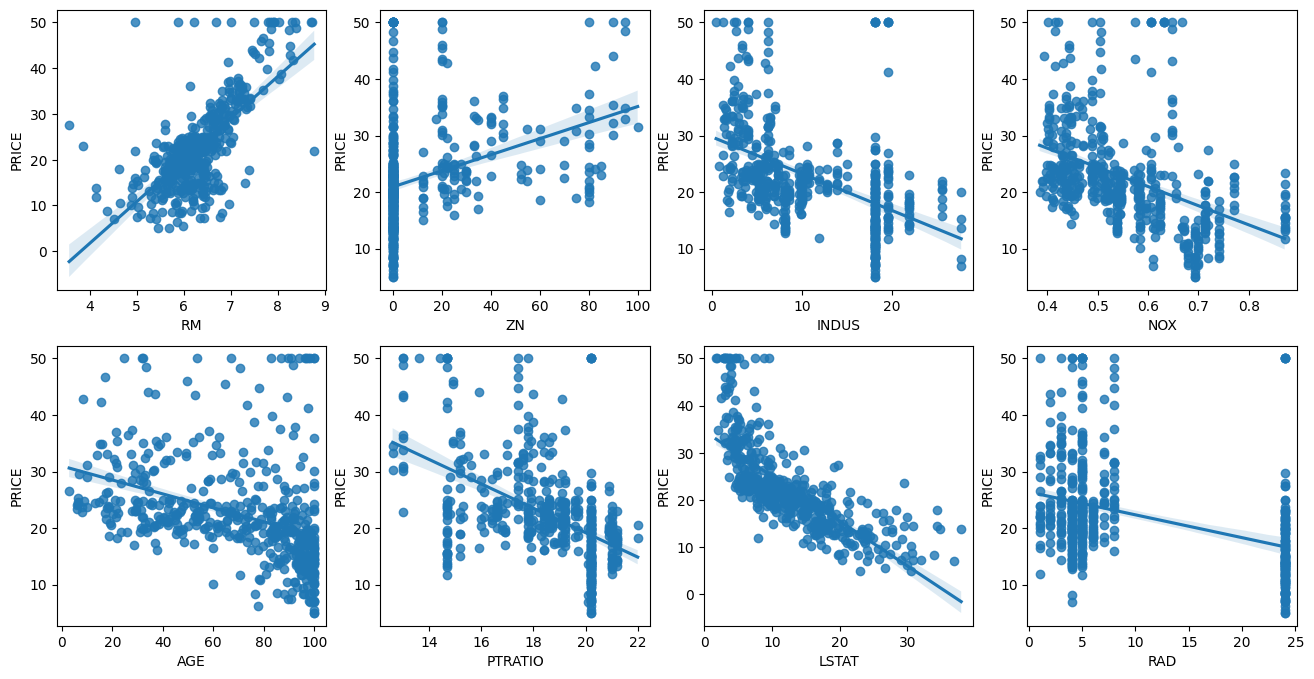

In [18]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
  row = int(i/4)
  col = i%4
  # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
  sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

- RM(방 개수)은 양의 선형 관계로, 방이 많을수록 PRICE가 크게 증가한다.
- LSTAT(하위 계층 비율)은 음의 선형 관계로, 비율이 낮을수록 PRICE가 높아진다.

In [20]:
# LinearRegression으로 모델을 학습하고, mean_squared_error와 r2_score로 성능 평가
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

# 선형 회귀 OLS로 학습/예측/평가 수행.
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE: {0:.3f}, RMSE: {1:.3F}'.format(mse, rmse))
print('Variance score: {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE: 17.297, RMSE: 4.159
Variance score: 0.757


In [21]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns)
coeff.sort_values(ascending=False)

,0
RM,3.4
CHAS,3.0
RAD,0.4
ZN,0.1
INDUS,0.0
B,0.0
TAX,-0.0
AGE,0.0
CRIM,-0.1
LSTAT,-0.6


- RM은 양의 영향으로 회귀 계수가 크고, NOX는 큰 음수 계수로 PRICE에 부정적 영향을 준다.
- cross_val_score()에서 scoring='neg_mean_squared_error'를 사용하면 MSE에 -1이 곱된 값이 반환된다.
- 따라서 다시 -1을 곱해 MSE로 복원한 뒤, sqrt()를 적용해 RMSE를 계산한다.

In [24]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

# cross_val_score()로 5폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함.
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수
print('5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print('5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 2))
print('5 folds의 평균 RMSE: {0:.3f} '.format(avg_rmse))

5 folds의 개별 Negative MSE scores:  [-12.46 -26.05 -33.07 -80.76 -33.31]
5 folds의 개별 RMSE scores:  [3.53 5.1  5.75 8.99 5.77]
5 folds의 평균 RMSE: 5.829 


##5.5 다항 회귀와 과(대)적합/과소적합 이해
###다항 회귀 이해
- 다항 회귀는 독립변수를 2차, 3차처럼 확장해 더 복잡한 곡선 관계를 표현하는 회귀 방법이다.
- 하지만 회귀 계수는 여전히 선형 구조이므로 비선형 회귀가 아니라 선형 회귀의 확장이다.
- 사이킷런은 다항 회귀 클래스를 직접 제공하지 않지만, PolynomialFeatures로 피처를 변환해 선형 회귀로 구현한다.

$y=w0​+w1​x1​+w2​x2​+w3​x12​+w4​x1​x2​+w5​x22​$

#### PolynomialFeatures를 이용해 단항값 $[x_1, x_2]$를 2차 다항값으로 $[1, x_1, x_2, x_1^2, x_1 x_2, x_2^2]$로 변환하는 예제

In [25]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1], [2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 피처:\n', X)

# degree=2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이요해 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 피처:\n', poly_ftr)

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


####PolynomialFeatures와 LinearRegression 클래스를 이용해 3차 다항 회귀 함수식을 유도

In [26]:
def polynomial_func(X):
  y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
  return y

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature: \n', X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [27]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n', poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀 계수 \n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape:', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수 
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape: (10,)


- 3차 다항 회귀로 변환하면 피처 수가 늘어나면서 회귀 계수도 10개로 증가한다.
- LinearRegression을 적용하면 원래 다항식 계수와 정확히 같지는 않지만, 데이터를 근사하는 형태로 학습된다.
- 이러한 “피처 변환 + 회귀” 과정은 PolynomialFeatures와 LinearRegression을 함께 사용하는데, 이를 Pipeline으로 묶어 한 번에 구현할 수 있다.

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
  y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
  return y

# Pipeline 객체로 Steamline하게 Polynomial Feature 변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)

print('Polynomial 회귀 계수 \n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수 
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


###다항 회귀를 이용한 과소적합 및 과적합 이해
- 차수가 높아질수록 과적합 문제가 크게 발생.
  - 학습 데이터에만 맞춘 학습이 이뤄져 테스터 데이터 환경에서 예측 정확도 떨어짐.
____
- 이 예제는 잡음이 포함된 코사인 형태 데이터(X, y)를 만들어 회귀 모델이 어떻게 학습되는지 보여준다.
- 다항 회귀의 차수(degree)를 바꿔가며 회귀 곡선이 데이터에 어떻게 맞춰지는지 비교한다.
- 이를 통해 차수가 낮으면 과소적합, 너무 높으면 과적합이 발생하는 현상을 시각적으로 확인한다.



In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
  return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree 1 회귀 계수 [-1.61] 입니다.
Degree 1 MSE 는 0.4077289625098685 입니다.

Degree 4 회귀 계수 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987232064 입니다.

Degree 15 회귀 계수 [-2.98293000e+03  1.03899390e+05 -1.87416123e+06  2.03716219e+07
 -1.44873283e+08  7.09315363e+08 -2.47065792e+09  6.24561050e+09
 -1.15676510e+10  1.56894936e+10 -1.54006023e+10  1.06457264e+10
 -4.91377530e+09  1.35919645e+09 -1.70380786e+08] 입니다.
Degree 15 MSE 는 181238256.56423894 입니다.


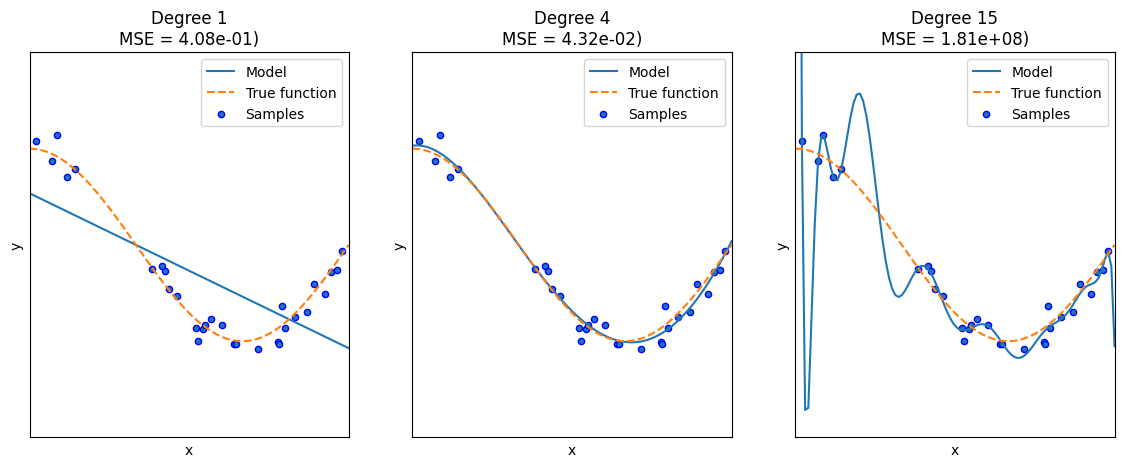

In [34]:
plt.figure(figsize=(14,5))
degrees = [1,4,15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
  ax = plt.subplot(1, len(degrees), i+1)
  plt.setp(ax, xticks=(), yticks=())

  # 개별 degree별로 Polynomial 변환합니다.
  polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
  linear_regression = LinearRegression()
  pipeline = Pipeline([('polynomial_features', polynomial_features),
                       ('linear_regression', linear_regression)])
  pipeline.fit(X.reshape(-1,1), y)

  # 교차 검증으로 다항 회귀를 평가합니다.
  scores = cross_val_score(pipeline, X.reshape(-1,1), y, scoring='neg_mean_squared_error', cv=10)
  # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
  coefficients = pipeline.named_steps['linear_regression'].coef_
  print('\nDegree {0} 회귀 계수 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
  print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))

  # 0부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
  # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
  X_test = np.linspace(0, 1, 100)
  # 예측값 곡선
  plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
  # 실제 값 곡선
  plt.plot(X_test, true_fun(X_test), '--', label="True function")
  plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

  plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0,1)); plt.ylim((-2,2)); plt.legend(loc='best')
  plt.title('Degree {}\nMSE = {:.2e})'.format(degrees[i], -scores.mean(), scores.std()))

plt.show()

- Degree 1은 직선 형태라 코사인 패턴을 전혀 따라가지 못해 과소적합이며 MSE가 약 0.41로 비교적 크다.
- Degree 4는 실제 코사인 곡선을 잘 따라가면서 잡음까지 적절히 반영해 가장 좋은 일반화 성능(MSE 약 0.04)을 보인다. => Balanced
- Degree 15는 잡음까지 과하게 학습해 학습 데이터에만 맞는 과적합 모델이 되어 MSE가 매우 크게 증가한다.

###편향-분산 트레이드오프(Bias-Variance Trade off)
- 편향-분산 트레이드오프는 모델 성능을 결정하는 핵심 문제로, 단순한 모델은 고편향(High Bias), 복잡한 모델은 고분산(High Variance) 문제가 발생한다.
- 고편향 모델은 과소적합처럼 패턴을 제대로 못 잡고, 고분산 모델은 과적합처럼 데이터에 과도하게 민감해진다.
- 이상적인 모델은 **낮은 편향과 낮은 분산(Low Bias / Low Variance)**을 동시에 갖는 경우로, 실제 값에 가깝고 안정적인 예측을 한다.
___
- 편향과 분산은 서로 트레이드오프 관계라서, 한쪽을 줄이면 다른 한쪽은 증가하는 경향이 있다.
- 편향이 너무 높으면 과소적합으로 오류가 크고, 분산이 너무 높으면 과적합으로 오류가 다시 커진다.
- 따라서 두 값을 적절히 균형 맞춰 전체 오류가 가장 낮아지는 골디락스 지점의 모델을 찾는 것이 핵심이다.